# Figure S15 (Assembly-based activity)

In [1]:
### load packages
import math
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

import os
import random
import numpy as np

# Set all possible seeds
np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [2]:
### load coverm results to identify viruses detected in bulk and enriched
df_lst = []

for file in glob.glob('../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/referenceanalyze/coverm/*/*.coverm.tsv.gz'):
    sample_id = file.split('/')[-1].split('.')[0]
    group = sample_id.rsplit('_', 1)[0]
    df = (
        pl.read_csv(file, separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'])
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.lit(group).alias('group')
            ])
            .with_columns([
                (pl.col('covered_bases')/pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
    )
    df_lst.append(df)

coverm_df = pl.concat(df_lst)
# coverm_df.write_csv('liang_activity_profiling_coverm_results.tsv', separator='\t')

In [3]:
phage_host_ratio_lst = []
sylph_tax_results = []

for file in glob.glob('../figure_4/sylph_tax_results/*.sylphmpa'):
    sample_id=file.split('/')[-1].split('.syl')[0]
    df = pl.read_csv(file, separator='\t', skip_rows=1, new_columns=['clade_name', 'taxonomic_abundance', 'relative_abundance', 'ani', 'coverage', 'virus_host'], null_values=['NA'], schema_overrides={'clade_name': pl.Utf8, 'taxonomic_abundance': pl.Float64, 'relative_abundance': pl.Float64, 'ani': pl.Float64, 'coverage': pl.Float64, 'virus_host': pl.Utf8})
    virus_df = df.filter(pl.col('virus_host').is_not_null()).with_columns([pl.col('virus_host').str.replace_all(';', '|')])
    sylph_tax_results.append(
        df
            .filter(pl.col('clade_name').str.starts_with('Viruses'))
            .filter(pl.col('clade_name').str.contains('t__'))
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )
    bac_df = df.filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    phage_host_ratio_lst.append(
        virus_df
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )

phage_host_ratio_df = pl.concat(phage_host_ratio_lst)[['sample_id', 'species_cluster_id', 'phage_host_ratio']]
sylph_tax_results_df = pl.concat(sylph_tax_results)

In [4]:
# load checkv results for unenriched 
checkv_lst = []
for file in glob.glob('../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/classify/new_mq_plus_classify.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            [['seq_name', 'topology', 'n_hallmarks', 'contig_length', 'proviral_length', 'viral_genes', 'host_genes', 'provirus', 'completeness', 'completeness_method']]
    )
    checkv_lst.append(df)

checkv_df = (
    pl.concat(checkv_lst)
        .with_columns([
            pl.when(pl.col('contig_length').is_not_null()).then(pl.col('contig_length')).otherwise(pl.col('proviral_length')).alias('contig_length')
        ])
        .group_by('seq_name')
        .agg([
            ((pl.col('topology').str.contains('TR')) | (pl.col('completeness_method').str.contains('TR'))).sum().alias('circular_count'),
            (pl.col('completeness').max()).alias('max_completeness'),
            (pl.col('n_hallmarks').max()).alias('max_n_hallmarks'),
            (pl.col('viral_genes').max()).alias('max_viral_genes'),
            (pl.col('host_genes').max()).alias('max_host_genes'),
            (pl.col('contig_length').max()).alias('max_contig_length'),
        ])
)

# load propagate results for unenriched
propagate_lst = []
for file in glob.glob('../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/assemblyanalyze/propagate/liang_*unenriched/liang_*unenriched.propagate.tsv.gz'):
    # skip if empty df
    try:
        df = (
            pl.read_csv(file, separator='\t', null_values=['NA'], columns=['prophage', 'prophage_len', 'host', 'CohenD', 'host_len', 'prophage-host_ratio'])
                .with_columns([
                    pl.col('prophage').cast(pl.String),
                    pl.col('host').cast(pl.String),
                    pl.col('prophage_len').cast(pl.Int64),
                    pl.col('CohenD').cast(pl.Float64),
                    pl.col('prophage-host_ratio').cast(pl.Float64),
                    pl.col('prophage').str.split('_k').list[0].alias('sample_id')
                ])
        )
        propagate_lst.append(df)
    except:
        pass

propagate_df = (
    pl.concat(propagate_lst)
)
# propagate_df.write_csv('liang_activity_profiling_propagate.tsv', separator='\t')


# identify mvirs active viruses in unenriched
!zcat ../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/assemblyanalyze/mvirs/liang_*unenriched/liang_*unenriched.mvirs.fasta.gz | \
    grep "^>" > unenriched_mvirs_contig_ids.txt

mvirs_contigs = (
    pl.read_csv('../figure_4/unenriched_mvirs_contig_ids.txt', separator=' ', has_header=False, new_columns=['mvirs_id'])
        .with_columns([
            pl.col('mvirs_id').str.replace('>', '').str.split(':').list[0].alias('contig_id_no_prophage'),
            pl.col('mvirs_id').str.split('OPRs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_oprs'),
            pl.col('mvirs_id').str.split('HSs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_clipped'),
        ])
        .with_columns([
            pl.col('contig_id_no_prophage').str.split('_k').list[0].alias('sample_id')
        ])
)
# mvirs_contigs.write_csv('liang_activity_profiling_mvirs.tsv', separator='\t')

In [5]:
# load final metadata and get species consensus
uhvdb_final_metadata = pl.read_csv('../figure_s17/uhvdb_v5_final_metadata.tsv.gz', separator='\t')
genome_to_species = uhvdb_final_metadata.select(['uhvdb_id', 'species_cluster_id']).unique()

In [6]:
### load unenriched vs uhvdb blast results
unenriched_v_uhvdb = pl.read_csv('../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/assemblyanalyze/vclust_new2all/new_mq_plus_viruses/new_mq_plus_viruses.ani.tsv', separator='\t')

vclust_sample_lst = []
for sample in list(set(coverm_df['sample_id'])):
    df = unenriched_v_uhvdb.filter(pl.col('query').str.contains(sample))
    uhvdb_hits_in_sample = set(coverm_df.filter((pl.col('sample_id') == sample) & (pl.col('breadth_ratio') >= 0.6))['contig_id'])
    vclust_sample_lst.append(
        df.filter(pl.col('reference').is_in(uhvdb_hits_in_sample))
            .sort('gani', descending=True)
            .unique('query', maintain_order=True)
            .unique(['reference'], maintain_order=True)
            .with_columns([pl.lit(sample).alias('sample_id')])
            .filter(pl.col('gani') >= 0.0)
    )
unenriched_v_uhvdb_vclust = pl.concat(vclust_sample_lst).join(genome_to_species, left_on='reference', right_on='uhvdb_id', how='left')

In [7]:
# aggregate to species level
uhvdb_final_metadata_species = (
    coverm_df
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df.filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='left'
        )
        .filter(pl.col('contig_id').is_not_null())
        .join(genome_to_species, left_on='contig_id', right_on='uhvdb_id', how='left')
        .join(uhvdb_final_metadata, on='species_cluster_id', how='left')
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('contig_id') == pl.col('genomovar_rep'))
        .join(unenriched_v_uhvdb_vclust[['query', 'gani', 'ani', 'sample_id', 'species_cluster_id']], on=['species_cluster_id', 'sample_id'], how='left')
        .join(checkv_df, left_on='query', right_on='seq_name', how='left')
        .join(propagate_df, left_on=['query', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .with_columns([
            pl.col('query').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(mvirs_contigs[['contig_id_no_prophage', 'num_oprs', 'num_clipped', 'sample_id']], on=['contig_id_no_prophage', 'sample_id'], how='left')
        .group_by(['species_cluster_id', 'sample_id', 'group'])
        .agg([
            (pl.col('checkv_quality') == 'Complete').sum().alias('complete_count'),
            (pl.col('checkv_quality') == 'High-quality').sum().alias('high_quality_count'),
            (pl.col('n_hallmarks')).median().alias('med_n_hallmarks'),
            ((pl.col('aai_id')/100) * pl.col('aai_af')).median().alias('med_aai_id_af'),
            (pl.col('viral_genes')).median().alias('med_viral_genes'),
            (pl.col('host_genes')).median().alias('med_host_genes'),
            (pl.col('ani')).median().alias('assem_med_ani'),
            (pl.col('circular_count')).median().alias('assem_complete_count'),
            (pl.col('max_n_hallmarks')).median().alias('assem_med_n_hallmarks'),
            (pl.col('max_contig_length')).median().alias('assem_med_contig_length'),
            (pl.col('max_viral_genes')).median().alias('assem_med_viral_genes'),
            (pl.col('max_host_genes')).median().alias('assem_med_host_genes'),
            (pl.col('CohenD')).median().alias('assem_med_cohend'),
            (pl.col('prophage-host_ratio')).median().alias('assem_med_prophage_host'),
            (pl.col('num_oprs').median()).alias('assem_med_num_oprs'),
            (pl.col('num_clipped').median()).alias('assem_med_num_clipped'),
            (pl.col('virulent').median()).alias('med_virulent_score'),
            ((pl.col('phrog_integration_excision')).median() + (pl.col('empathi_integration')).median()).alias('med_integration_related'),
            (pl.col('num_capsid').median()).alias('med_num_capsid'),
            (pl.col('num_tail').median()).alias('med_num_tail'),
            (pl.col('num_lysis').median()).alias('med_num_lysis'),
            (pl.col('mcp_hallmark').median()).alias('med_mcp_hallmark'),
            (pl.col('terl_hallmark').median()).alias('med_terL_hallmark'),
            (pl.col('portal_hallmark').median()).alias('med_portal_hallmark'),
            (pl.col('breadth').median()).alias('breadth'),
            (pl.col('breadth_enriched').median()).alias('breadth_enriched'),
            (pl.col('breadth_ratio').median()).alias('breadth_ratio'),
            (pl.col('breadth_ratio_enriched').median()).alias('breadth_ratio_enriched'),
            (pl.col('variance').median()).alias('variance'),
            (pl.col('trimmed_mean').median()).alias('trimmed_mean'),
            (pl.col('length').median()).alias('genome_length'),
        ])
        .join(phage_host_ratio_df, left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .join(sylph_tax_results_df.select(['species_cluster_id', 'sample_id', 'ani']), left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .unique(['species_cluster_id', 'sample_id'])
        .fill_null(0.00)
)
uhvdb_final_metadata_species.head(1)

species_cluster_id,sample_id,group,complete_count,high_quality_count,med_n_hallmarks,med_aai_id_af,med_viral_genes,med_host_genes,assem_med_ani,assem_complete_count,assem_med_n_hallmarks,assem_med_contig_length,assem_med_viral_genes,assem_med_host_genes,assem_med_cohend,assem_med_prophage_host,assem_med_num_oprs,assem_med_num_clipped,med_virulent_score,med_integration_related,med_num_capsid,med_num_tail,med_num_lysis,med_mcp_hallmark,med_terL_hallmark,med_portal_hallmark,breadth,breadth_enriched,breadth_ratio,breadth_ratio_enriched,variance,trimmed_mean,genome_length,phage_host_ratio,ani
f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
141035.0,"""liang_4001_unenriched""","""liang_4001""",0.0,1.0,5.0,51.237864,10.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.05,30.0,5.0,21.0,0.0,1.0,0.0,1.0,0.65672,0.0,0.662535,0.0,77.19302,4.307123,114877.0,0.0,96.68


In [29]:
print("Total detected species:", uhvdb_final_metadata_species.filter(pl.col('breadth_ratio') >= 0.6).height)
print("Number of detected species with an assembly:", uhvdb_final_metadata_species.filter(pl.col('assem_med_ani') > 0).height)

Total detected species: 2841
Number of detected species with an assembly: 568


In [30]:
568/2841

0.1999296022527279

In [8]:
print("Number of true positives:", uhvdb_final_metadata_species.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false negatives:", uhvdb_final_metadata_species.filter((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false positives:", uhvdb_final_metadata_species.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6)).height)

enrich_v_unenrich = (
    uhvdb_final_metadata_species
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
)
print(859/(859+1982))

Number of true positives: 859
Number of false negatives: 21
Number of false positives: 1982
0.30235832453361494


In [21]:
enrich_v_unenrich_assem = enrich_v_unenrich
print("Assembly TP rate at random:", enrich_v_unenrich_assem.filter(pl.col('assem_med_ani') > 0).filter(pl.col('pr_cat') == 'TP').height / enrich_v_unenrich_assem.filter(pl.col('assem_med_ani') > 0).height)
print("Number of assemblies:", enrich_v_unenrich_assem.filter(pl.col('assem_med_ani') > 0).height)
print("Number of assembly TPs:", enrich_v_unenrich_assem.filter(pl.col('assem_med_ani') > 0).filter(pl.col('pr_cat') == 'TP').height)

Assembly TP rate at random: 0.5211267605633803
Number of assemblies: 568
Number of assembly TPs: 296


0.3445867287543655


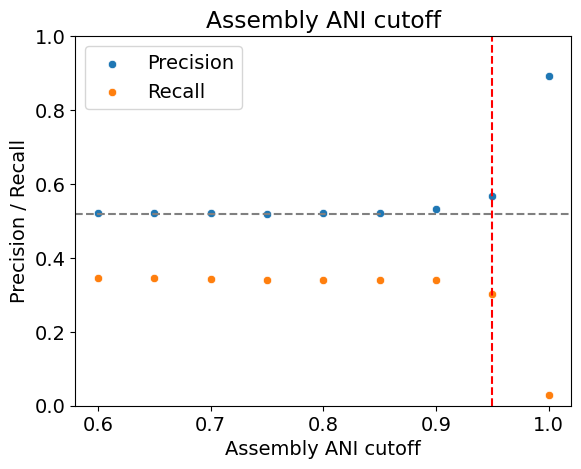

In [22]:
### Assembly ANI to UHVDB
precision_values = []
recall_values = []

print(enrich_v_unenrich_assem
            .filter(pl.col('assem_med_ani') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich_assem
            .filter(pl.col('assem_med_ani') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_ani') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_ani') >= i)
            .filter(pl.col('assem_med_ani') > 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_ani') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1],
    y=precision_values
)
sns.scatterplot(
    x=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1],
    y=recall_values
)
plt.axhline(y=0.52, color='grey', linestyle='--')
plt.axvline(x=0.95, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Assembly ANI cutoff')
plt.ylabel('Precision / Recall')
plt.title('Assembly ANI cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.059371362048894066


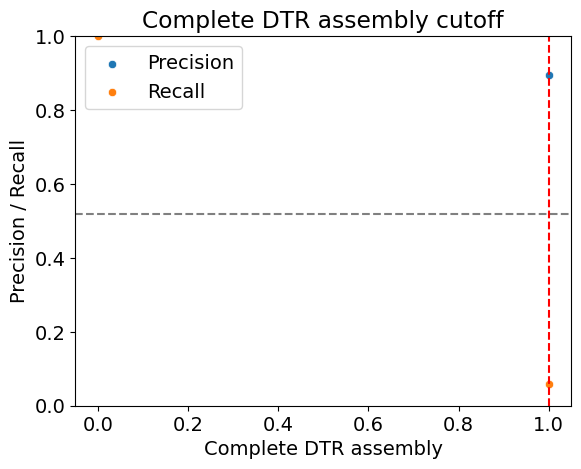

In [23]:
### Complete DTR assembly cutoff
precision_values = []
recall_values = []

print(enrich_v_unenrich_assem
            .filter(pl.col('assem_complete_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 1, 2, 3]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich_assem
            .filter(pl.col('assem_complete_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_complete_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter(pl.col('assem_complete_count') >= i)
            .filter(pl.col('assem_med_ani') > 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_complete_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3],
    y=recall_values
)
plt.axhline(y=0.52, color='grey', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Complete DTR assembly')
plt.ylabel('Precision / Recall')
plt.title('Complete DTR assembly cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.03259604190919674


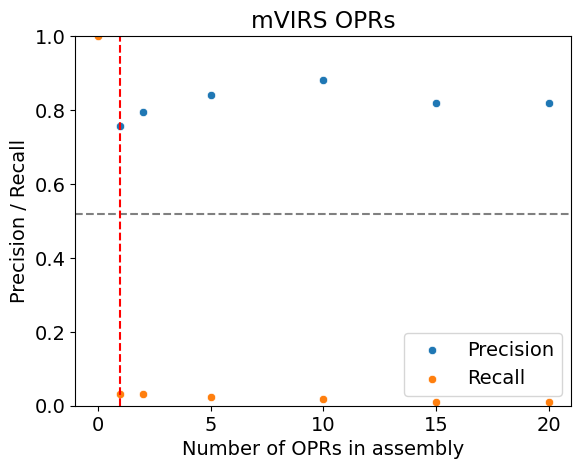

In [24]:
### mVIRS OPRs
precision_values = []
recall_values = []

print(enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_oprs') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 1, 2, 5, 10, 15, 20]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_oprs') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_oprs') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_oprs') >= i)
            .filter(pl.col('assem_med_ani') > 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_oprs') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 5, 10, 15, 20],
    y=recall_values
)
plt.axhline(y=0.52, color='grey', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Number of OPRs in assembly')
plt.ylabel('Precision / Recall')
plt.title('mVIRS OPRs')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.03259604190919674


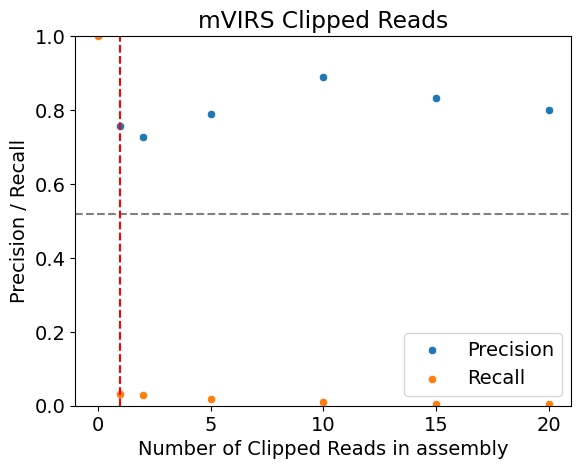

In [25]:
### mVIRS Clipped
precision_values = []
recall_values = []

print(enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_clipped') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 1, 2, 5, 10, 15, 20]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_clipped') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_clipped') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_clipped') >= i)
            .filter(pl.col('assem_med_ani') > 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_num_clipped') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 5, 10, 15, 20],
    y=recall_values
)
plt.axhline(y=0.52, color='grey', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Number of Clipped Reads in assembly')
plt.ylabel('Precision / Recall')
plt.title('mVIRS Clipped Reads')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.17578579743888242


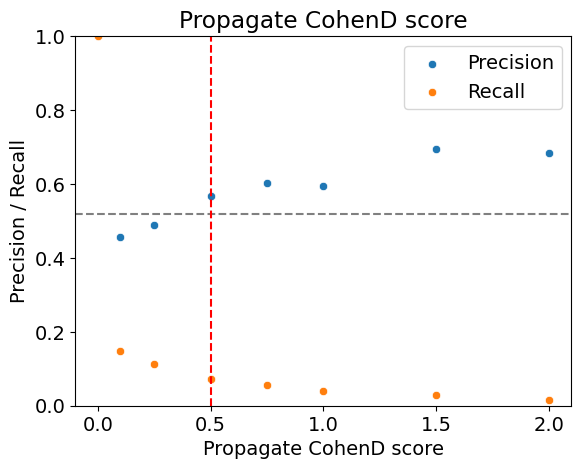

In [26]:
### Propagate CohenD
precision_values = []
recall_values = []

print(enrich_v_unenrich_assem
            .filter(pl.col('assem_med_cohend') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 5, 10, 15, 20]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich_assem
            .filter(pl.col('assem_med_cohend') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_cohend') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_cohend') >= i)
            .filter(pl.col('assem_med_ani') > 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_cohend') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 5, 10, 15, 20],
    y=recall_values
)
plt.axhline(y=0.52, color='grey', linestyle='--')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Propagate CohenD score')
plt.ylabel('Precision / Recall')
plt.title('Propagate CohenD score')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.17578579743888242


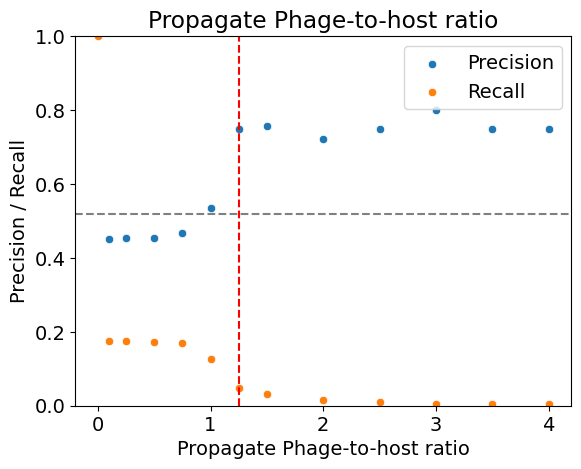

In [27]:
### Propagate Phage-to-host ratio
precision_values = []
recall_values = []

print(enrich_v_unenrich_assem
            .filter(pl.col('assem_med_prophage_host') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 2, 2.5, 3, 3.5, 4 ]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich_assem
            .filter(pl.col('assem_med_prophage_host') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_prophage_host') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_prophage_host') >= i)
            .filter(pl.col('assem_med_ani') > 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich_assem
            .filter(pl.col('assem_med_prophage_host') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_assem
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 2, 2.5, 3, 3.5, 4 ],
    y=precision_values
)
sns.scatterplot(
    x=[0, 0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 2, 2.5, 3, 3.5, 4 ],
    y=recall_values
)
plt.axhline(y=0.52, color='grey', linestyle='--')
plt.axvline(x=1.25, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Propagate Phage-to-host ratio')
plt.ylabel('Precision / Recall')
plt.title('Propagate Phage-to-host ratio')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [16]:
enrich_v_unenrich_final = (
    enrich_v_unenrich
    .with_columns([
        (pl.col('variance')/pl.col('trimmed_mean')).alias('variance_ratio'),
    ])
    [[
        'group', 'species_cluster_id', 'pr_cat',
        'breadth', 'breadth_ratio', 'variance_ratio', 'complete_count', 'high_quality_count',
        'med_integration_related', 'med_virulent_score', 'med_viral_genes', 'med_host_genes', 'med_n_hallmarks',
        'med_aai_id_af', 'med_num_lysis', 'med_num_tail', 'med_num_capsid', 'med_mcp_hallmark',
        'med_portal_hallmark', 'med_terL_hallmark', 'phage_host_ratio', 'ani', 'assem_med_ani',
        'assem_complete_count', 'assem_med_num_oprs', 'assem_med_num_clipped', 'assem_med_cohend', 'assem_med_prophage_host',
    ]]
    .sort(['group', 'species_cluster_id'])
)
enrich_v_unenrich_final.tail(5)

group,species_cluster_id,pr_cat,breadth,breadth_ratio,variance_ratio,complete_count,high_quality_count,med_integration_related,med_virulent_score,med_viral_genes,med_host_genes,med_n_hallmarks,med_aai_id_af,med_num_lysis,med_num_tail,med_num_capsid,med_mcp_hallmark,med_portal_hallmark,med_terL_hallmark,phage_host_ratio,ani,assem_med_ani,assem_complete_count,assem_med_num_oprs,assem_med_num_clipped,assem_med_cohend,assem_med_prophage_host
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""liang_4284""",194797.0,"""TP""",0.3203,0.844599,6.818659,1.0,0.0,10.0,0.0375,9.0,0.0,5.0,100.0,3.0,6.0,6.0,1.0,1.0,1.0,1.210702,99.34,0.0,0.0,0.0,0.0,0.0,0.0
"""liang_4284""",203153.0,"""TP""",0.975208,0.975208,5.003248,0.0,1.0,8.0,0.0,16.0,4.0,11.0,59.487233,0.0,7.0,5.0,1.0,1.0,1.0,0.965526,99.66,0.999953,0.0,0.0,0.0,0.312817,1.08363
"""liang_4284""",204347.0,"""TP""",0.812012,0.812024,5.000278,0.0,1.0,0.0,0.975,26.0,3.0,13.0,72.851035,2.0,6.0,7.0,1.0,1.0,1.0,0.0,97.91,0.972344,0.0,0.0,0.0,0.0,0.0
"""liang_4284""",205220.0,"""TP""",0.808008,0.836194,6.322109,0.0,1.0,3.0,0.0,26.0,1.0,11.0,64.996347,4.0,9.0,6.0,1.0,1.0,1.0,2.405457,97.57,0.0,0.0,0.0,0.0,0.0,0.0
"""liang_4284""",205575.0,"""FP""",0.378641,0.785983,3.013651,0.0,1.0,4.0,0.0,34.0,1.0,19.0,52.327165,4.0,13.0,5.0,1.0,1.0,1.0,0.0,96.4,0.0,0.0,0.0,0.0,0.0,0.0


/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting Group K-Fold Cross-Validation (k=5)
 fold    AUROC    AUPRC      MCC
    1 0.734120 0.768594 0.253212
    2 0.683254 0.697571 0.303175
    3 0.715091 0.793144 0.331445
    4 0.823182 0.853816 0.466141
    5 0.815328 0.843690 0.509085

Pooled metrics across all folds:
  AUROC : 0.753
  AUPRC : 0.785
  MCC   : 0.373


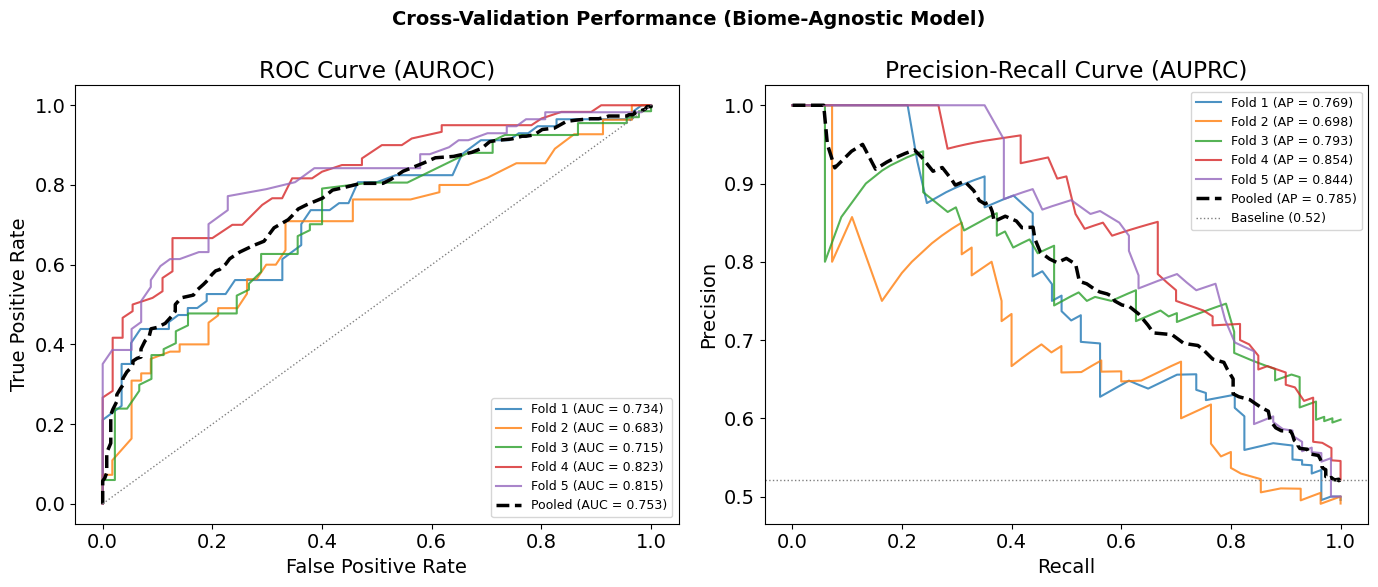


Generating SHAP summary plot for Active class (Class 1)...


/tmp/ipykernel_67463/3365735963.py:187: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


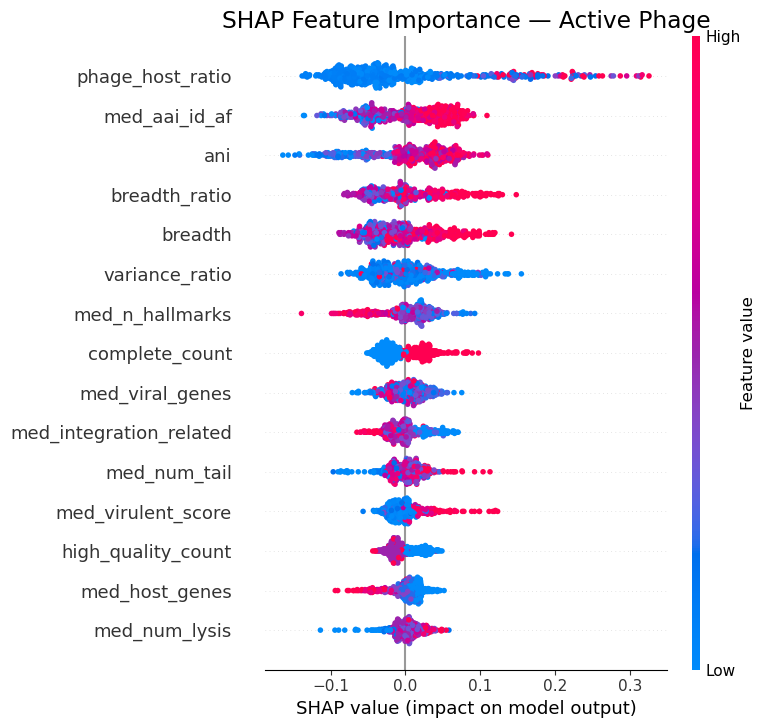

In [17]:
# model of using refs with assemblies without assembly features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import shap

# =============================================================================
# 1. LOAD DATA (Using the mock data dictionary)
# =============================================================================
df = enrich_v_unenrich_final.filter(pl.col('assem_med_ani') > 0).to_pandas()

# =============================================================================
# 2. DEFINE TARGET VARIABLE
# =============================================================================
df = df[df["pr_cat"].isin(["TP", "FP"])].copy()
df["is_active"] = (df["pr_cat"] == "TP").astype(int)

# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================


# =============================================================================
# 4. DROP LEAKAGE, IDENTIFIERS, & ECOLOGY-SPECIFIC COLUMNS
# =============================================================================
cols_to_drop = [
    # Identifiers & Targets
    "species_cluster_id",
    "sample_id",               
    "group",                   
    "pr_cat",                  
    "is_active",               
    # Leakage
    "breadth_enriched",        
    "breadth_ratio_enriched",  
    # Dropped to prevent ecological overfitting (Gut -> Airways)
    "most_common_ictv_class",
    "most_common_family_cluster_id",
    "most_common_host_taxonomy",
    # drop any column starting with "assem_"
    *df.filter(regex="^assem_").columns.tolist()
]

groups = df["group"]
y = df["is_active"]
X = df.drop(columns=cols_to_drop, errors="ignore")

# All remaining columns are numeric
numeric_cols = X.columns.tolist()

# =============================================================================
# 5. BUILD PURELY NUMERIC PIPELINE
# =============================================================================
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_cols),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

# =============================================================================
# 6. GROUP K-FOLD CROSS-VALIDATION
# =============================================================================
n_splits = min(5, df['group'].nunique()) 
gkf = GroupKFold(n_splits=n_splits)

fold_results = []
all_y_test, all_y_proba, all_y_pred = [], [], []
fold_roc_curves, fold_pr_curves = [], []

print("=" * 60)
print(f"Starting Group K-Fold Cross-Validation (k={n_splits})")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    if len(np.unique(y_test)) > 1:
        auc   = roc_auc_score(y_test, y_proba)
        auprc = average_precision_score(y_test, y_proba)
        mcc   = matthews_corrcoef(y_test, y_pred)
        
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        fold_roc_curves.append((fpr, tpr, auc))
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        fold_pr_curves.append((recall, precision, auprc))
    else:
        auc, auprc, mcc = np.nan, np.nan, np.nan

    fold_results.append({"fold": fold + 1, "AUROC": auc, "AUPRC": auprc, "MCC": mcc})
    all_y_test.extend(y_test.tolist())
    all_y_proba.extend(y_proba.tolist())
    all_y_pred.extend(y_pred.tolist())

# =============================================================================
# 7. AGGREGATE RESULTS
# =============================================================================
results_df = pd.DataFrame(fold_results).dropna()
print(results_df.to_string(index=False))

if len(np.unique(all_y_test)) > 1:
    print("\nPooled metrics across all folds:")
    print(f"  AUROC : {roc_auc_score(all_y_test, all_y_proba):.3f}")
    print(f"  AUPRC : {average_precision_score(all_y_test, all_y_proba):.3f}")
    print(f"  MCC   : {matthews_corrcoef(all_y_test, all_y_pred):.3f}")

# =============================================================================
# 8. AUROC AND AUPRC PLOTS
# =============================================================================
if len(fold_roc_curves) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Cross-Validation Performance (Biome-Agnostic Model)", fontsize=14, fontweight="bold")

    # ROC
    ax = axes[0]
    for i, (fpr, tpr, auc) in enumerate(fold_roc_curves):
        ax.plot(fpr, tpr, lw=1.5, alpha=0.8, label=f"Fold {i+1} (AUC = {auc:.3f})")
    
    pool_fpr, pool_tpr, _ = roc_curve(all_y_test, all_y_proba)
    ax.plot(pool_fpr, pool_tpr, color="black", lw=2.5, linestyle="--", label=f"Pooled (AUC = {roc_auc_score(all_y_test, all_y_proba):.3f})")
    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
    ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve (AUROC)")
    ax.legend(fontsize=9, loc="lower right")

    # PR
    ax = axes[1]
    baseline = sum(all_y_test) / len(all_y_test)
    for i, (recall, precision, auprc) in enumerate(fold_pr_curves):
        ax.plot(recall, precision, lw=1.5, alpha=0.8, label=f"Fold {i+1} (AP = {auprc:.3f})")
        
    pool_precision, pool_recall, _ = precision_recall_curve(all_y_test, all_y_proba)
    ax.plot(pool_recall, pool_precision, color="black", lw=2.5, linestyle="--", label=f"Pooled (AP = {average_precision_score(all_y_test, all_y_proba):.3f})")
    ax.axhline(y=baseline, color="grey", lw=1, linestyle=":", label=f"Baseline ({baseline:.2f})")
    ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve (AUPRC)")
    ax.legend(fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.show()

# =============================================================================
# 9. FINAL MODEL & SHAP INTERPRETATION
# =============================================================================
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1))
])
final_pipeline.fit(X, y)

# Transform X manually so SHAP can interpret the numeric arrays
X_transformed = final_pipeline.named_steps["preprocessor"].transform(X)

# Because we only have numeric features left, we just map them directly back
X_transformed_df = pd.DataFrame(X_transformed, columns=numeric_cols)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(final_pipeline.named_steps["classifier"])
shap_explanation = explainer(X_transformed_df)

print("\nGenerating SHAP summary plot for Active class (Class 1)...")
shap.summary_plot(
    shap_explanation[:, :, 1],   
    X_transformed_df,
    max_display=15,
    plot_type="dot",
    show=False,
)
plt.title("SHAP Feature Importance — Active Phage")
plt.tight_layout()
plt.show()

Starting Group K-Fold Cross-Validation (k=5)
 fold    AUROC    AUPRC      MCC
    1 0.747126 0.785631 0.341611
    2 0.697608 0.714870 0.303175
    3 0.731177 0.822205 0.281063
    4 0.785909 0.809421 0.415149
    5 0.815020 0.845472 0.473976

Pooled metrics across all folds:
  AUROC : 0.754
  AUPRC : 0.789
  MCC   : 0.366


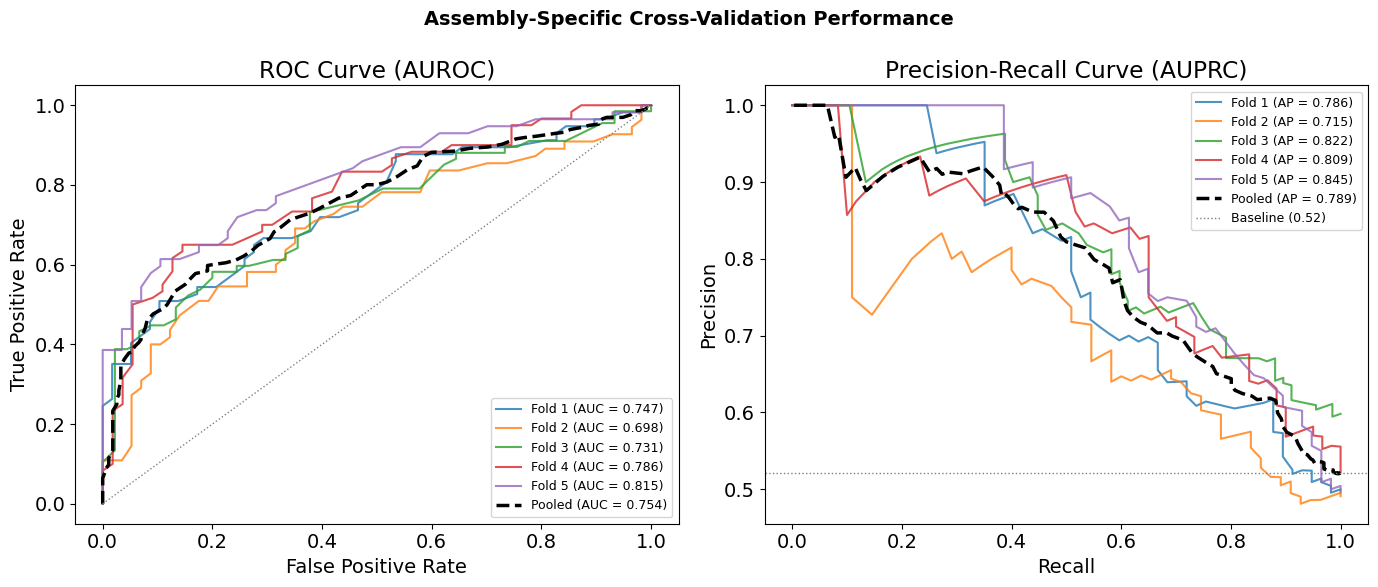


Generating SHAP summary plot for Active class (Class 1)...


/tmp/ipykernel_67463/3813529127.py:185: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


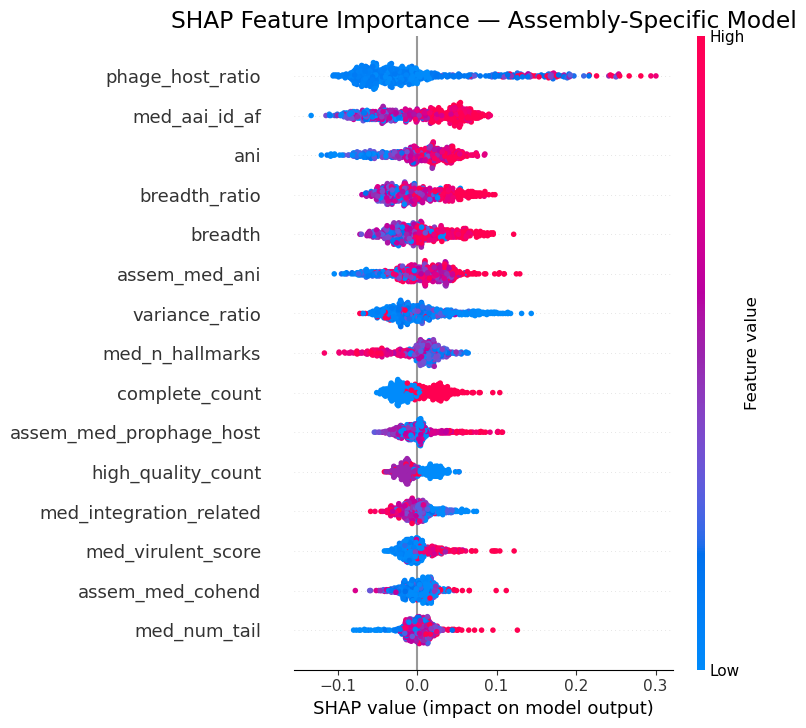

In [18]:
# model of using refs with assemblies with assembly features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import shap

# =============================================================================
# 1. LOAD DATA (Using the mock data dictionary)
# =============================================================================
df = enrich_v_unenrich_final.filter(pl.col('assem_med_ani') > 0).to_pandas()

# =============================================================================
# 2. DEFINE TARGET VARIABLE
# =============================================================================
df = df[df["pr_cat"].isin(["TP", "FP"])].copy()
df["is_active"] = (df["pr_cat"] == "TP").astype(int)

# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================


# =============================================================================
# 4. DROP LEAKAGE, IDENTIFIERS, & ECOLOGY-SPECIFIC COLUMNS
# =============================================================================
cols_to_drop = [
    # Identifiers & Targets
    "species_cluster_id",
    "sample_id",               
    "group",                   
    "pr_cat",                  
    "is_active",               
    # Leakage
    "breadth_enriched",        
    "breadth_ratio_enriched",  
    # Dropped to prevent ecological overfitting (Gut -> Airways)
    "most_common_ictv_class",
    "most_common_family_cluster_id",
    "most_common_host_taxonomy",
]

groups = df["group"]
y = df["is_active"]
X = df.drop(columns=cols_to_drop, errors="ignore")

# All remaining columns are numeric
numeric_cols = X.columns.tolist()

# =============================================================================
# 5. BUILD PURELY NUMERIC PIPELINE
# =============================================================================
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_cols),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

# =============================================================================
# 6. GROUP K-FOLD CROSS-VALIDATION
# =============================================================================
n_splits = min(5, df['group'].nunique()) 
gkf = GroupKFold(n_splits=n_splits)

fold_results = []
all_y_test, all_y_proba, all_y_pred = [], [], []
fold_roc_curves, fold_pr_curves = [], []

print("=" * 60)
print(f"Starting Group K-Fold Cross-Validation (k={n_splits})")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    if len(np.unique(y_test)) > 1:
        auc   = roc_auc_score(y_test, y_proba)
        auprc = average_precision_score(y_test, y_proba)
        mcc   = matthews_corrcoef(y_test, y_pred)
        
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        fold_roc_curves.append((fpr, tpr, auc))
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        fold_pr_curves.append((recall, precision, auprc))
    else:
        auc, auprc, mcc = np.nan, np.nan, np.nan

    fold_results.append({"fold": fold + 1, "AUROC": auc, "AUPRC": auprc, "MCC": mcc})
    all_y_test.extend(y_test.tolist())
    all_y_proba.extend(y_proba.tolist())
    all_y_pred.extend(y_pred.tolist())

# =============================================================================
# 7. AGGREGATE RESULTS
# =============================================================================
results_df = pd.DataFrame(fold_results).dropna()
print(results_df.to_string(index=False))

if len(np.unique(all_y_test)) > 1:
    print("\nPooled metrics across all folds:")
    print(f"  AUROC : {roc_auc_score(all_y_test, all_y_proba):.3f}")
    print(f"  AUPRC : {average_precision_score(all_y_test, all_y_proba):.3f}")
    print(f"  MCC   : {matthews_corrcoef(all_y_test, all_y_pred):.3f}")

# =============================================================================
# 8. AUROC AND AUPRC PLOTS
# =============================================================================
if len(fold_roc_curves) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Assembly-Specific Cross-Validation Performance", fontsize=14, fontweight="bold")

    # ROC
    ax = axes[0]
    for i, (fpr, tpr, auc) in enumerate(fold_roc_curves):
        ax.plot(fpr, tpr, lw=1.5, alpha=0.8, label=f"Fold {i+1} (AUC = {auc:.3f})")
    
    pool_fpr, pool_tpr, _ = roc_curve(all_y_test, all_y_proba)
    ax.plot(pool_fpr, pool_tpr, color="black", lw=2.5, linestyle="--", label=f"Pooled (AUC = {roc_auc_score(all_y_test, all_y_proba):.3f})")
    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
    ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve (AUROC)")
    ax.legend(fontsize=9, loc="lower right")

    # PR
    ax = axes[1]
    baseline = sum(all_y_test) / len(all_y_test)
    for i, (recall, precision, auprc) in enumerate(fold_pr_curves):
        ax.plot(recall, precision, lw=1.5, alpha=0.8, label=f"Fold {i+1} (AP = {auprc:.3f})")
        
    pool_precision, pool_recall, _ = precision_recall_curve(all_y_test, all_y_proba)
    ax.plot(pool_recall, pool_precision, color="black", lw=2.5, linestyle="--", label=f"Pooled (AP = {average_precision_score(all_y_test, all_y_proba):.3f})")
    ax.axhline(y=baseline, color="grey", lw=1, linestyle=":", label=f"Baseline ({baseline:.2f})")
    ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve (AUPRC)")
    ax.legend(fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.show()

# =============================================================================
# 9. FINAL MODEL & SHAP INTERPRETATION
# =============================================================================
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1))
])
final_pipeline.fit(X, y)

# Transform X manually so SHAP can interpret the numeric arrays
X_transformed = final_pipeline.named_steps["preprocessor"].transform(X)

# Because we only have numeric features left, we just map them directly back
X_transformed_df = pd.DataFrame(X_transformed, columns=numeric_cols)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(final_pipeline.named_steps["classifier"])
shap_explanation = explainer(X_transformed_df)

print("\nGenerating SHAP summary plot for Active class (Class 1)...")
shap.summary_plot(
    shap_explanation[:, :, 1],   
    X_transformed_df,
    max_display=15,
    plot_type="dot",
    show=False,
)
plt.title("SHAP Feature Importance — Assembly-Specific Model")
plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# 10. THRESHOLD CALIBRATION & RECALL ESTIMATION
# =============================================================================
# Calculate precision, recall, and thresholds from CV results
precisions, recalls, thresholds = precision_recall_curve(all_y_test, all_y_proba)

def get_target_metrics(target_precision, precisions, recalls, thresholds):
    # Find the first index where precision meets or exceeds target
    idx = np.where(precisions >= target_precision)[0]
    if len(idx) > 0:
        return {
            "threshold": thresholds[idx[0]],
            "recall": recalls[idx[0]]
        }
    return {"threshold": 1.0, "recall": 0.0}

# Get metrics for your two targets
metrics_90 = get_target_metrics(0.90, precisions, recalls, thresholds)
metrics_75 = get_target_metrics(0.75, precisions, recalls, thresholds)
metrics_50 = get_target_metrics(0.50, precisions, recalls, thresholds)

thresh_90, recall_90 = metrics_90["threshold"], metrics_90["recall"]
thresh_75, recall_75 = metrics_75["threshold"], metrics_75["recall"]
thresh_50, recall_50 = metrics_50["threshold"], metrics_50["recall"]
print("-" * 30)
print(f"ESTIMATED PERFORMANCE (OOF):")
print(f"High Conf (90% Prec) -> Threshold: {thresh_90:.4f} | Est. Recall: {recall_90:.1%}")
print(f"Med  Conf (75% Prec) -> Threshold: {thresh_75:.4f} | Est. Recall: {recall_75:.1%}")
print(f"Low  Conf (50% Prec) -> Threshold: {thresh_50:.4f} | Est. Recall: {recall_50:.1%}")
print("-" * 30)

------------------------------
ESTIMATED PERFORMANCE (OOF):
High Conf (90% Prec) -> Threshold: 0.7700 | Est. Recall: 36.5%
Med  Conf (75% Prec) -> Threshold: 0.5600 | Est. Recall: 60.1%
Low  Conf (50% Prec) -> Threshold: 0.0300 | Est. Recall: 100.0%
------------------------------


In [20]:
import joblib

# Group the necessary metadata together
model_metadata = {
    "numeric_cols": numeric_cols,
    "thresh_90": thresh_90,
    "thresh_75": thresh_75,
    "thresh_50": thresh_50,
}

# Save the pipeline and the metadata to disk
joblib.dump(final_pipeline, "phage_activity_model_assembly.joblib")
joblib.dump(model_metadata, "phage_model_metadata_assembly.joblib")

print("Model and metadata successfully saved!")

Model and metadata successfully saved!
